# Project 10 — Supply-Chain Disruption & Delivery-Risk Prediction

## Predict late delivery before shipment is completed

This project builds an operational machine-learning system around the **DataCo Global Supply Chain** dataset.

### Business question
At order time, which shipments are most likely to arrive late, and where should an operations team intervene first?

### Leakage rule
The model must behave as if it is making a decision **before delivery has happened**.

Therefore we deliberately exclude:
- `Days for shipping (real)`
- `Delivery Status`
- `shipping date (DateOrders)`
- any post-outcome status fields
- customer names, email, password, street, IDs and other identifiers

The target is `Late_delivery_risk`.

### What this notebook demonstrates
- public supply-chain data ingestion
- privacy-aware feature selection
- temporal train / validation / test split
- preprocessing for numeric and categorical data
- Logistic Regression baseline
- HistGradientBoosting classifier
- validation-only threshold selection
- ROC-AUC, PR-AUC, precision, recall and F1
- risk-decile lift
- market / shipping-mode risk analysis
- permutation importance
- PII-safe intervention queue
- reproducible integrity checks

> The model predicts delivery-delay risk from historical operational data. It is not a guarantee of future delivery performance.

In [1]:
# Install only the small dataset helper when needed.
import sys, subprocess, importlib.util

if importlib.util.find_spec("kagglehub") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])

print("Environment ready.")

Environment ready.


In [2]:
from pathlib import Path
import warnings, hashlib
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Libraries imported.")

Libraries imported.


## 1. Download and load DataCo

The public dataset contains structured supply-chain transactions covering provisioning, sales and commercial distribution.

In [3]:
import kagglehub

dataset_dir = Path(
    kagglehub.dataset_download(
        "shashwatwork/dataco-smart-supply-chain-for-big-data-analysis"
    )
)

csv_files = list(dataset_dir.rglob("DataCoSupplyChainDataset.csv"))
if not csv_files:
    csv_files = [
        p for p in dataset_dir.rglob("*.csv")
        if "description" not in p.name.lower()
        and "tokenized" not in p.name.lower()
    ]

if not csv_files:
    raise FileNotFoundError("DataCo structured CSV not found.")

csv_path = csv_files[0]
raw = pd.read_csv(csv_path, encoding="latin1", low_memory=False)

print("Loaded:", csv_path.name)
print(f"Rows: {len(raw):,}")
print(f"Columns: {len(raw.columns)}")
display(raw.head())

  0%|          | 0.00/25.7M [00:00<?, ?B/s]

  4%|▍         | 1.00M/25.7M [00:00<00:04, 6.32MB/s]

 23%|██▎       | 6.00M/25.7M [00:00<00:00, 27.4MB/s]

 58%|█████▊    | 15.0M/25.7M [00:00<00:00, 53.3MB/s]

 82%|████████▏ | 21.0M/25.7M [00:00<00:00, 54.5MB/s]

100%|██████████| 25.7M/25.7M [00:00<00:00, 53.9MB/s]

Extracting files...


Loaded: DataCoSupplyChainDataset.csv
Rows: 180,519
Columns: 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 2. Data-quality and leakage audit

A late-delivery model can look unrealistically strong if it is allowed to see fields produced after shipping. This section makes the exclusion policy explicit.

In [4]:
target_col = "Late_delivery_risk"
date_col = "order date (DateOrders)"

if target_col not in raw.columns:
    raise ValueError(f"Expected target {target_col!r} was not found.")

data = raw.copy()
data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
data[target_col] = pd.to_numeric(data[target_col], errors="coerce").astype("Int64")
data = data.dropna(subset=[target_col, date_col]).copy()
data[target_col] = data[target_col].astype(int)

explicit_leakage = [
    "Days for shipping (real)",
    "Delivery Status",
    "shipping date (DateOrders)",
    "Order Status"
]

privacy_and_ids = [
    "Customer Email","Customer Fname","Customer Lname","Customer Password",
    "Customer Street","Customer Id","Order Customer Id","Order Id",
    "Order Item Id","Product Card Id","Order Item Cardprod Id"
]

available_leakage = [c for c in explicit_leakage if c in data.columns]
available_privacy = [c for c in privacy_and_ids if c in data.columns]

print("Late-delivery rate:", f"{data[target_col].mean():.2%}")
print("Post-outcome fields excluded:", available_leakage)
print("PII / identifier fields excluded:", available_privacy)
print("Order-date range:", data[date_col].min(), "->", data[date_col].max())

Late-delivery rate: 54.83%
Post-outcome fields excluded: ['Days for shipping (real)', 'Delivery Status', 'shipping date (DateOrders)', 'Order Status']
PII / identifier fields excluded: ['Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Street', 'Customer Id', 'Order Customer Id', 'Order Id', 'Order Item Id', 'Product Card Id', 'Order Item Cardprod Id']
Order-date range: 2015-01-01 00:00:00 -> 2018-01-31 23:38:00


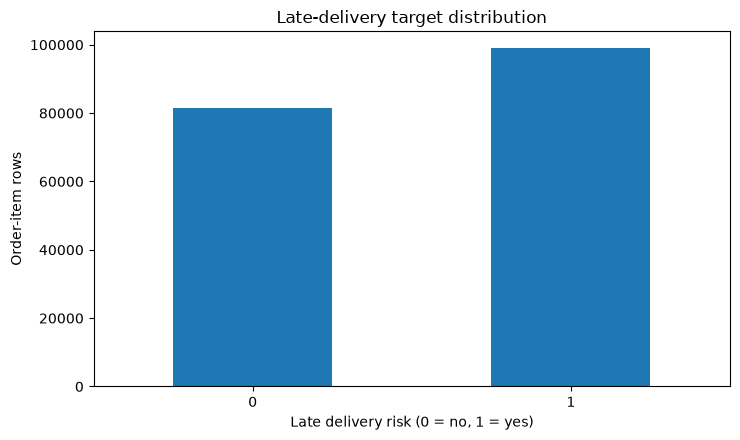

,count,mean
Shipping Mode,,
First Class,27814,95.32%
Second Class,35216,76.63%
Same Day,9737,45.74%
Standard Class,107752,38.07%


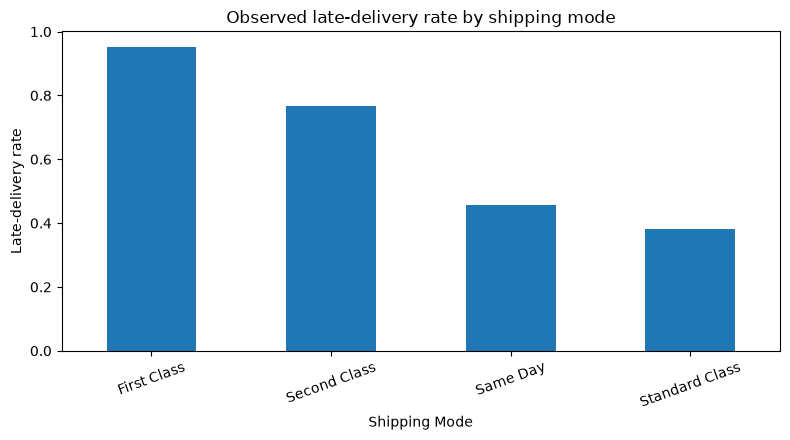

In [5]:
fig, ax = plt.subplots(figsize=(7.5,4.5))
data[target_col].value_counts().sort_index().plot(kind="bar",ax=ax)
ax.set_title("Late-delivery target distribution")
ax.set_xlabel("Late delivery risk (0 = no, 1 = yes)")
ax.set_ylabel("Order-item rows")
ax.tick_params(axis="x",rotation=0)
plt.tight_layout()
plt.show()

if "Shipping Mode" in data.columns:
    mode_rates = (
        data.groupby("Shipping Mode")[target_col]
        .agg(["count","mean"])
        .sort_values("mean",ascending=False)
    )
    display(mode_rates.style.format({"mean":"{:.2%}"}))

    fig, ax = plt.subplots(figsize=(8,4.5))
    mode_rates["mean"].plot(kind="bar",ax=ax)
    ax.set_title("Observed late-delivery rate by shipping mode")
    ax.set_ylabel("Late-delivery rate")
    ax.tick_params(axis="x",rotation=20)
    plt.tight_layout()
    plt.show()

## 3. Pre-dispatch feature set

These variables are available or derivable around order placement / shipping-plan time. High-cardinality IDs and outcome-derived fields are not used.

In [6]:
candidate_numeric = [
    "Days for shipment (scheduled)",
    "Benefit per order",
    "Sales per customer",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Product Price",
    "Order Item Quantity",
    "Sales",
    "Order Profit Per Order",
    "Order Item Profit Ratio"
]

candidate_categorical = [
    "Type",
    "Customer Segment",
    "Department Name",
    "Market",
    "Order Region",
    "Order Country",
    "Category Name",
    "Shipping Mode"
]

numeric_features = [c for c in candidate_numeric if c in data.columns]
categorical_features = [c for c in candidate_categorical if c in data.columns]

# Calendar signals known at order time.
data["order_month"] = data[date_col].dt.month
data["order_dayofweek"] = data[date_col].dt.dayofweek
data["order_hour"] = data[date_col].dt.hour
numeric_features += ["order_month","order_dayofweek","order_hour"]

features = numeric_features + categorical_features

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Total model features:", len(features))

for forbidden in available_leakage + available_privacy:
    assert forbidden not in features

display(data[features + [target_col]].head())

Numeric features: ['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Quantity', 'Sales', 'Order Profit Per Order', 'Order Item Profit Ratio', 'order_month', 'order_dayofweek', 'order_hour']
Categorical features: ['Type', 'Customer Segment', 'Department Name', 'Market', 'Order Region', 'Order Country', 'Category Name', 'Shipping Mode']
Total model features: 21


,Days for shipment (scheduled),Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Quantity,Sales,Order Profit Per Order,Order Item Profit Ratio,order_month,order_dayofweek,order_hour,Type,Customer Segment,Department Name,Market,Order Region,Order Country,Category Name,Shipping Mode,Late_delivery_risk
0,4,91.250000,314.640015,13.110000,0.04,327.75,1,327.75,91.250000,0.29,1,2,22,DEBIT,Consumer,Fitness,Pacific Asia,Southeast Asia,Indonesia,Sporting Goods,Standard Class,0
1,4,-249.089996,311.359985,16.389999,0.05,327.75,1,327.75,-249.089996,-0.80,1,5,12,TRANSFER,Consumer,Fitness,Pacific Asia,South Asia,India,Sporting Goods,Standard Class,1
2,4,-247.779999,309.720001,18.030001,0.06,327.75,1,327.75,-247.779999,-0.80,1,5,12,CASH,Consumer,Fitness,Pacific Asia,South Asia,India,Sporting Goods,Standard Class,0
3,4,22.860001,304.809998,22.940001,0.07,327.75,1,327.75,22.860001,0.08,1,5,11,DEBIT,Home Office,Fitness,Pacific Asia,Oceania,Australia,Sporting Goods,Standard Class,0
4,4,134.210007,298.250000,29.500000,0.09,327.75,1,327.75,134.210007,0.45,1,5,11,PAYMENT,Corporate,Fitness,Pacific Asia,Oceania,Australia,Sporting Goods,Standard Class,0


## 4. Chronological train / validation / test split

A future-looking deployment should be tested on later orders, not a random mixture of the same time period.

We use order dates to create:
- earliest 60% → training
- next 20% → validation
- latest 20% → untouched test

All rows sharing a date boundary are kept on the corresponding side of the cutoff.

In [7]:
sorted_dates = np.sort(data[date_col].dropna().unique())
train_cutoff = sorted_dates[int(len(sorted_dates)*0.60)]
val_cutoff = sorted_dates[int(len(sorted_dates)*0.80)]

train_df = data.loc[data[date_col] < train_cutoff].copy()
val_df = data.loc[
    (data[date_col] >= train_cutoff) & (data[date_col] < val_cutoff)
].copy()
test_df = data.loc[data[date_col] >= val_cutoff].copy()

split_summary = pd.DataFrame({
    "rows":[len(train_df),len(val_df),len(test_df)],
    "late_rate":[
        train_df[target_col].mean(),
        val_df[target_col].mean(),
        test_df[target_col].mean()
    ],
    "start":[
        train_df[date_col].min(),
        val_df[date_col].min(),
        test_df[date_col].min()
    ],
    "end":[
        train_df[date_col].max(),
        val_df[date_col].max(),
        test_df[date_col].max()
    ]
}, index=["train","validation","test"])

display(split_summary.style.format({"late_rate":"{:.2%}"}))

X_train = train_df[features]
y_train = train_df[target_col]
X_val = val_df[features]
y_val = val_df[target_col]
X_test = test_df[features]
y_test = test_df[target_col]

,rows,late_rate,start,end
train,118245,54.95%,2015-01-01 00:00:00,2016-11-21 09:32:00
validation,39496,54.46%,2016-11-21 10:14:00,2017-07-09 22:53:00
test,22778,54.83%,2017-07-09 23:14:00,2018-01-31 23:38:00


## 5. Preprocessing

Numeric fields receive median imputation and standardisation.

Categorical variables use ordinal encoding with an explicit unknown category so the later validation/test periods can contain previously unseen destinations or products without crashing the pipeline.

In [8]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ("num",numeric_pipe,numeric_features),
    ("cat",categorical_pipe,categorical_features)
])

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

print("Transformed train:", X_train_t.shape)
print("Transformed validation:", X_val_t.shape)
print("Transformed test:", X_test_t.shape)
print("Finite train matrix:", np.isfinite(X_train_t).all())

Transformed train: (118245, 21)
Transformed validation: (39496, 21)
Transformed test: (22778, 21)
Finite train matrix: True


## 6. Compare two model families on validation data

- **Logistic Regression** gives a transparent linear baseline.
- **HistGradientBoosting** captures nonlinear interactions between shipping plan, geography, order economics and product mix.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1500,
        class_weight="balanced",
        C=1.0,
        random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=250,
        max_leaf_nodes=31,
        min_samples_leaf=40,
        l2_regularization=1.0,
        random_state=RANDOM_STATE
    )
}

validation_rows=[]
fitted={}

for name,model in models.items():
    model.fit(X_train_t,y_train)
    prob=model.predict_proba(X_val_t)[:,1]
    fitted[name]=model
    validation_rows.append({
        "model":name,
        "ROC_AUC":roc_auc_score(y_val,prob),
        "PR_AUC":average_precision_score(y_val,prob)
    })

validation_results=pd.DataFrame(validation_rows).set_index("model")
display(validation_results.style.format({
    "ROC_AUC":"{:.4f}",
    "PR_AUC":"{:.4f}"
}))

champion_name = validation_results["PR_AUC"].idxmax()
champion = fitted[champion_name]
print("Validation-selected champion:",champion_name)

,ROC_AUC,PR_AUC
model,,
Logistic Regression,0.7192,0.7903
HistGradientBoosting,0.7624,0.8278


Validation-selected champion: HistGradientBoosting


## 7. Choose an intervention threshold on validation data only

The operating point prioritises recall while still seeking a useful F1 score. We require at least **70% recall** when possible, because missing a high-risk shipment can be more expensive than reviewing an extra order.

In [10]:
val_prob = champion.predict_proba(X_val_t)[:,1]

rows=[]
for t in np.linspace(0.05,0.95,181):
    pred=(val_prob>=t).astype(int)
    rows.append({
        "threshold":t,
        "precision":precision_score(y_val,pred,zero_division=0),
        "recall":recall_score(y_val,pred,zero_division=0),
        "F1":f1_score(y_val,pred,zero_division=0),
        "alert_rate":pred.mean()
    })

threshold_table=pd.DataFrame(rows)
eligible=threshold_table.loc[threshold_table["recall"]>=0.70]
chosen=(eligible if len(eligible) else threshold_table).sort_values(
    ["precision","F1","alert_rate"],ascending=[False,False,True]
).iloc[0]

risk_threshold=float(chosen["threshold"])

print(f"Frozen threshold: {risk_threshold:.3f}")
print(f"Validation precision: {chosen['precision']:.2%}")
print(f"Validation recall: {chosen['recall']:.2%}")
print(f"Validation F1: {chosen['F1']:.4f}")
print(f"Validation alert rate: {chosen['alert_rate']:.2%}")

Frozen threshold: 0.400
Validation precision: 68.61%
Validation recall: 72.10%
Validation F1: 0.7031
Validation alert rate: 57.23%


## 8. Final evaluation on the untouched future test period

,ROC_AUC,PR_AUC,precision,recall,F1,alert_rate
model,,,,,,
HistGradientBoosting,0.7752,0.8392,68.54%,75.80%,0.7199,60.65%


              precision    recall  f1-score   support

           0     0.6629    0.5776    0.6173     10288
           1     0.6854    0.7580    0.7199     12490

    accuracy                         0.6765     22778
   macro avg     0.6741    0.6678    0.6686     22778
weighted avg     0.6752    0.6765    0.6735     22778



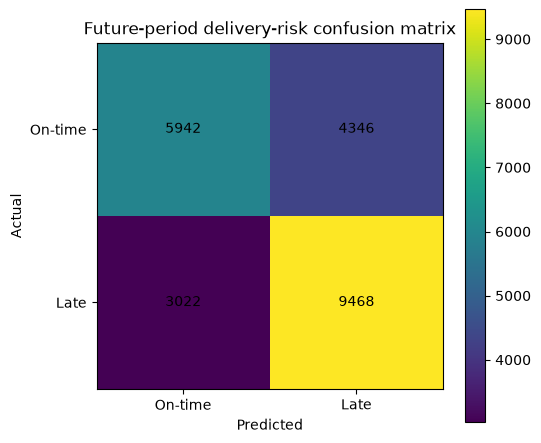

In [11]:
test_prob = champion.predict_proba(X_test_t)[:,1]
test_pred = (test_prob>=risk_threshold).astype(int)

test_metrics = {
    "model":champion_name,
    "ROC_AUC":roc_auc_score(y_test,test_prob),
    "PR_AUC":average_precision_score(y_test,test_prob),
    "precision":precision_score(y_test,test_pred,zero_division=0),
    "recall":recall_score(y_test,test_pred,zero_division=0),
    "F1":f1_score(y_test,test_pred,zero_division=0),
    "alert_rate":test_pred.mean()
}

display(pd.DataFrame([test_metrics]).set_index("model").style.format({
    "ROC_AUC":"{:.4f}",
    "PR_AUC":"{:.4f}",
    "precision":"{:.2%}",
    "recall":"{:.2%}",
    "F1":"{:.4f}",
    "alert_rate":"{:.2%}"
}))

print(classification_report(y_test,test_pred,digits=4))

cm=confusion_matrix(y_test,test_pred)
fig,ax=plt.subplots(figsize=(5.5,4.8))
im=ax.imshow(cm)
ax.set_title("Future-period delivery-risk confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0,1],["On-time","Late"])
ax.set_yticks([0,1],["On-time","Late"])
for i in range(2):
    for j in range(2):
        ax.text(j,i,cm[i,j],ha="center",va="center")
plt.colorbar(im,ax=ax)
plt.tight_layout()
plt.show()

## 9. Risk-decile lift

Operations teams rarely inspect every shipment. Ranking is therefore as important as binary classification.

We measure how much late-delivery volume is concentrated in the highest predicted-risk deciles.

,orders,actual_late,late_rate,avg_predicted_risk,lift_vs_average
risk_decile,,,,,
1,2278,2278,100.00%,99.93%,1.82x
2,2278,1996,87.62%,91.44%,1.60x
3,2278,1823,80.03%,79.71%,1.46x
4,2277,1514,66.49%,66.85%,1.21x
5,2278,908,39.86%,44.10%,0.73x
6,2278,891,39.11%,41.03%,0.71x
7,2277,856,37.59%,39.12%,0.69x
8,2278,859,37.71%,36.50%,0.69x
9,2278,796,34.94%,32.86%,0.64x


Top 10% risk bucket captures 18.23% of all late rows in the test period.


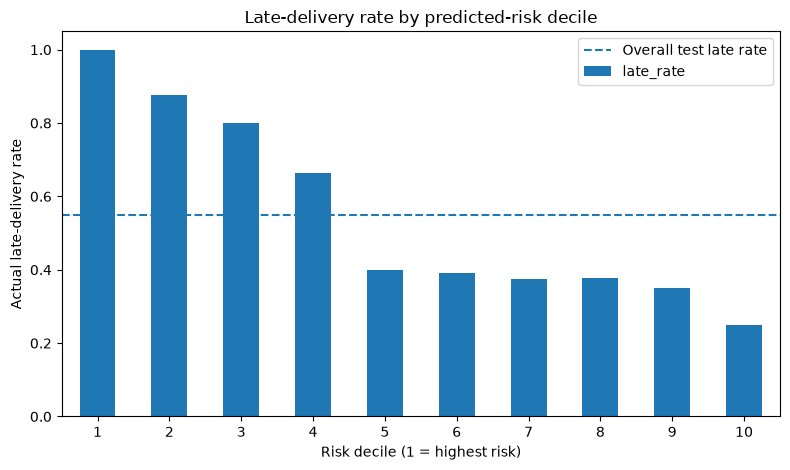

In [12]:
ranked = test_df[[target_col]].copy()
ranked["risk_probability"] = test_prob
ranked = ranked.sort_values("risk_probability",ascending=False).reset_index(drop=True)

ranked["risk_decile"] = pd.qcut(
    np.arange(len(ranked)),
    10,
    labels=[1,2,3,4,5,6,7,8,9,10]
)

deciles = (
    ranked.groupby("risk_decile",observed=True)
    .agg(
        orders=(target_col,"size"),
        actual_late=(target_col,"sum"),
        late_rate=(target_col,"mean"),
        avg_predicted_risk=("risk_probability","mean")
    )
)

base_rate = ranked[target_col].mean()
deciles["lift_vs_average"] = deciles["late_rate"] / base_rate

display(deciles.style.format({
    "late_rate":"{:.2%}",
    "avg_predicted_risk":"{:.2%}",
    "lift_vs_average":"{:.2f}x"
}))

top10 = ranked.head(max(1,int(len(ranked)*0.10)))
top10_capture = top10[target_col].sum() / ranked[target_col].sum()

print(f"Top 10% risk bucket captures {top10_capture:.2%} of all late rows in the test period.")

fig,ax=plt.subplots(figsize=(8,4.8))
deciles["late_rate"].plot(kind="bar",ax=ax)
ax.axhline(base_rate,linestyle="--",label="Overall test late rate")
ax.set_title("Late-delivery rate by predicted-risk decile")
ax.set_xlabel("Risk decile (1 = highest risk)")
ax.set_ylabel("Actual late-delivery rate")
ax.legend()
ax.tick_params(axis="x",rotation=0)
plt.tight_layout()
plt.show()

## 10. Operational segmentation

Which markets and shipping modes combine high predicted risk with meaningful shipment volume?

In [13]:
ops = test_df[[
    c for c in ["Market","Order Region","Shipping Mode",target_col]
    if c in test_df.columns
]].copy()
ops["predicted_risk"] = test_prob
ops["alert"] = test_pred

for group_col in ["Market","Shipping Mode","Order Region"]:
    if group_col not in ops.columns:
        continue
    table = (
        ops.groupby(group_col)
        .agg(
            rows=(target_col,"size"),
            actual_late_rate=(target_col,"mean"),
            avg_predicted_risk=("predicted_risk","mean"),
            alert_rate=("alert","mean")
        )
        .sort_values(["avg_predicted_risk","rows"],ascending=[False,False])
    )
    print("\n###",group_col)
    display(table.head(20).style.format({
        "actual_late_rate":"{:.2%}",
        "avg_predicted_risk":"{:.2%}",
        "alert_rate":"{:.2%}"
    }))


### Market


,rows,actual_late_rate,avg_predicted_risk,alert_rate
Market,,,,
Europe,17158,54.62%,55.30%,61.81%
Pacific Asia,5620,55.50%,55.13%,57.08%



### Shipping Mode


,rows,actual_late_rate,avg_predicted_risk,alert_rate
Shipping Mode,,,,
First Class,3449,94.75%,96.25%,99.97%
Second Class,4521,76.95%,76.80%,99.93%
Same Day,1302,52.46%,53.02%,55.22%
Standard Class,13506,37.46%,37.79%,37.98%



### Order Region


,rows,actual_late_rate,avg_predicted_risk,alert_rate
Order Region,,,,
Western Europe,10101,55.28%,56.08%,67.21%
South Asia,1119,56.03%,55.32%,54.42%
Eastern Asia,1316,55.24%,55.28%,58.59%
Oceania,1436,55.15%,55.11%,56.82%
Southern Europe,3478,54.03%,55.09%,54.86%
Southeast Asia,1749,55.63%,54.90%,57.86%
Northern Europe,3579,53.31%,53.28%,53.34%


## 11. Permutation importance

Feature importance is calculated on a deterministic validation sample using the frozen champion. This measures the drop in ROC-AUC when each transformed feature is shuffled.

,feature,importance_mean,importance_std
0,Days for shipment (scheduled),0.143682,0.003135
20,Shipping Mode,0.053566,0.002692
12,order_hour,0.043150,0.001264
13,Type,0.011030,0.001169
10,order_month,0.004434,0.001074
9,Order Item Profit Ratio,0.002245,0.000704
18,Order Country,0.001072,0.001524
1,Benefit per order,0.000797,0.000786
4,Order Item Discount Rate,0.000619,0.000557
11,order_dayofweek,0.000394,0.000903


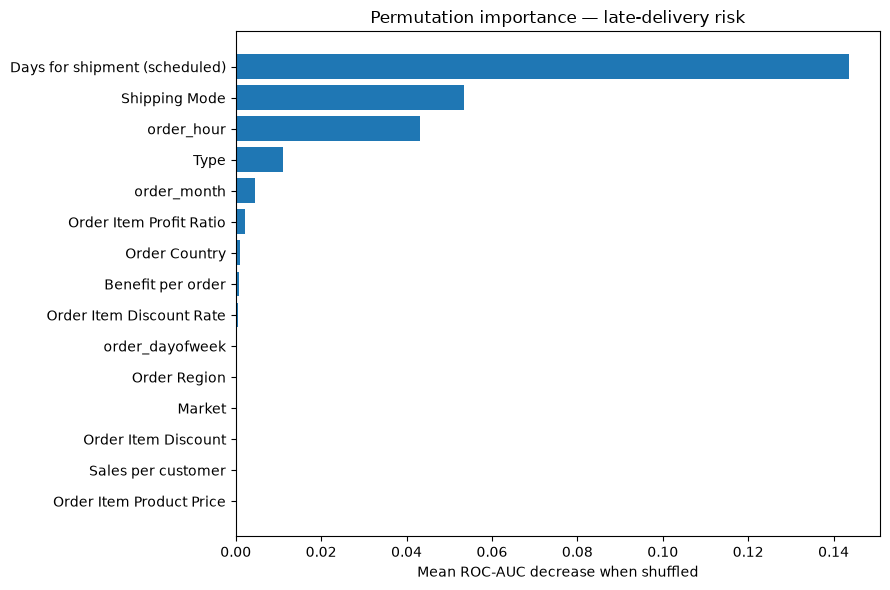

In [14]:
# Work on the original feature frame with a full pipeline so names remain interpretable.
champion_pipeline = Pipeline([
    ("prep",preprocessor),
    ("model",champion)
])

sample_n=min(12000,len(val_df))
importance_sample=val_df.sample(sample_n,random_state=RANDOM_STATE)
importance_y=importance_sample[target_col]

perm=permutation_importance(
    champion_pipeline,
    importance_sample[features],
    importance_y,
    scoring="roc_auc",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature":features,
    "importance_mean":perm.importances_mean,
    "importance_std":perm.importances_std
}).sort_values("importance_mean",ascending=False)

display(importance.head(20))

fig,ax=plt.subplots(figsize=(9,6))
top_imp=importance.head(15).sort_values("importance_mean")
ax.barh(top_imp["feature"],top_imp["importance_mean"])
ax.set_title("Permutation importance — late-delivery risk")
ax.set_xlabel("Mean ROC-AUC decrease when shuffled")
plt.tight_layout()
plt.show()

## 12. PII-safe intervention queue

The queue contains operational fields only. Customer names, email, street address, passwords and raw identifiers are deliberately excluded.

Recommended actions are simple transparent business rules layered on top of the model score.

In [15]:
queue_cols = [
    c for c in [
        date_col,"Market","Order Region","Order Country",
        "Shipping Mode","Category Name","Customer Segment",
        "Days for shipment (scheduled)","Sales","Order Item Quantity"
    ]
    if c in test_df.columns
]

queue=test_df[queue_cols].copy().reset_index(drop=True)
queue["late_risk_probability"]=test_prob
queue["risk_alert"]=test_pred

def action(row):
    if row["late_risk_probability"] >= max(0.80,risk_threshold):
        return "Expedite / carrier review"
    if row["risk_alert"] == 1:
        return "Proactive ETA check"
    return "Standard monitoring"

queue["recommended_action"]=queue.apply(action,axis=1)
queue["shipment_key"]=[
    "SHP-"+hashlib.sha256(f"{i}-{d}".encode()).hexdigest()[:8].upper()
    for i,d in enumerate(queue[date_col].astype(str))
]

queue=queue.sort_values(
    ["risk_alert","late_risk_probability"],
    ascending=[False,False]
).reset_index(drop=True)

print("Top intervention candidates:")
display(queue.head(30).style.format({
    "late_risk_probability":"{:.2%}"
}))

queue.to_csv("project10_delivery_risk_intervention_queue.csv",index=False)
importance.to_csv("project10_delivery_risk_feature_importance.csv",index=False)
deciles.to_csv("project10_delivery_risk_deciles.csv")

print("Operational artefacts exported without customer PII.")

Top intervention candidates:


,order date (DateOrders),Market,Order Region,Order Country,Shipping Mode,Category Name,Customer Segment,Days for shipment (scheduled),Sales,Order Item Quantity,late_risk_probability,risk_alert,recommended_action,shipment_key
0,2017-10-09 13:59:00,Europe,Western Europe,Suiza,First Class,CDs,Consumer,1,11.290000,1,99.98%,1,Expedite / carrier review,SHP-31397A65
1,2017-12-05 19:42:00,Pacific Asia,Eastern Asia,China,First Class,Toys,Corporate,1,11.540000,1,99.98%,1,Expedite / carrier review,SHP-61530ABA
2,2017-12-05 00:04:00,Pacific Asia,Oceania,Australia,First Class,Toys,Consumer,1,11.540000,1,99.98%,1,Expedite / carrier review,SHP-BE4F3BF9
3,2017-12-05 04:17:00,Pacific Asia,Oceania,Australia,First Class,Toys,Consumer,1,11.540000,1,99.97%,1,Expedite / carrier review,SHP-CEB0EA3E
4,2017-12-05 04:38:00,Pacific Asia,Oceania,Australia,First Class,Toys,Consumer,1,11.540000,1,99.97%,1,Expedite / carrier review,SHP-2916D95D
5,2017-09-23 22:46:00,Europe,Western Europe,Alemania,First Class,Fishing,Consumer,1,399.980011,1,99.97%,1,Expedite / carrier review,SHP-74B31D2D
6,2017-10-09 13:38:00,Europe,Western Europe,Suiza,First Class,CDs,Consumer,1,11.290000,1,99.97%,1,Expedite / carrier review,SHP-CF0D3FA7
7,2017-10-10 02:36:00,Europe,Southern Europe,España,First Class,CDs,Consumer,1,11.290000,1,99.97%,1,Expedite / carrier review,SHP-78039E29
8,2017-12-05 19:21:00,Pacific Asia,Eastern Asia,China,First Class,Toys,Consumer,1,11.540000,1,99.97%,1,Expedite / carrier review,SHP-A6B5C73A
9,2017-10-09 06:38:00,Europe,Northern Europe,Dinamarca,First Class,CDs,Consumer,1,11.290000,1,99.97%,1,Expedite / carrier review,SHP-109D4927


Operational artefacts exported without customer PII.


## 13. Integrity checks

In [16]:
assert target_col not in features
assert all(c not in features for c in available_leakage)
assert all(c not in features for c in available_privacy)
assert train_df[date_col].max() < val_df[date_col].min()
assert val_df[date_col].max() < test_df[date_col].min()
assert len(test_prob) == len(test_df)
assert np.isfinite(test_prob).all()
assert ((test_prob>=0)&(test_prob<=1)).all()

print("All Project 10 integrity checks passed ✅")

All Project 10 integrity checks passed ✅


## 14. Executive summary

In [17]:
print(f"""
PROJECT 10 — SUPPLY-CHAIN DELIVERY-RISK INTELLIGENCE
====================================================
Dataset rows used: {len(data):,}
Model features: {len(features)}
Train rows: {len(train_df):,}
Validation rows: {len(val_df):,}
Future test rows: {len(test_df):,}

Champion model: {champion_name}
Frozen intervention threshold: {risk_threshold:.3f}

Future-period ROC-AUC: {test_metrics['ROC_AUC']:.4f}
Future-period PR-AUC: {test_metrics['PR_AUC']:.4f}
Precision: {test_metrics['precision']:.2%}
Recall: {test_metrics['recall']:.2%}
F1: {test_metrics['F1']:.4f}
Alert rate: {test_metrics['alert_rate']:.2%}

Top-10%-risk capture of late rows: {top10_capture:.2%}

LEAKAGE CONTROL
---------------
Actual shipping time used as feature: NO
Delivery Status used as feature: NO
Shipping completion date used as feature: NO
Customer PII / raw IDs used as features: NO

The system produces a ranked, PII-safe intervention queue for operations.
""")


PROJECT 10 — SUPPLY-CHAIN DELIVERY-RISK INTELLIGENCE
Dataset rows used: 180,519
Model features: 21
Train rows: 118,245
Validation rows: 39,496
Future test rows: 22,778

Champion model: HistGradientBoosting
Frozen intervention threshold: 0.400

Future-period ROC-AUC: 0.7752
Future-period PR-AUC: 0.8392
Precision: 68.54%
Recall: 75.80%
F1: 0.7199
Alert rate: 60.65%

Top-10%-risk capture of late rows: 18.23%

LEAKAGE CONTROL
---------------
Actual shipping time used as feature: NO
Delivery Status used as feature: NO
Shipping completion date used as feature: NO
Customer PII / raw IDs used as features: NO

The system produces a ranked, PII-safe intervention queue for operations.



### Production roadmap
- retrain on a company's current carrier and fulfilment data;
- engineer warehouse, carrier, route distance, weather and capacity signals;
- calibrate probabilities by carrier/region;
- model time-to-delivery as a survival / quantile problem;
- estimate intervention cost versus avoided-delay cost;
- monitor temporal drift and carrier performance;
- expose predictions through an API and operations dashboard;
- validate intervention impact through controlled operational experiments.

### Interview defence
**“I built the model around the moment an operator could actually act. I removed actual shipping duration and final delivery status because they leak the answer, split the data chronologically to simulate future orders, selected the model and threshold only on validation data, and converted the final probability into a ranked intervention queue rather than treating classification accuracy as the business objective.”**